# Прогноз удовлетворённости клиента для маркетплейса Olist
## Часть 2. Разведочный анализ данных (EDA)

**Автор:** Adilkhan Iskindirov

---

### Бизнес-вопрос

Можно ли предсказать, что клиент поставит низкую оценку (1–2 звезды), **до того
как он её оставил** — используя только данные, известные в момент доставки заказа?

Если да, бизнес может вмешаться заранее: извиниться, дать компенсацию или
промокод клиенту из группы риска, не дожидаясь публичного негатива.

### Что делает этот ноутбук

Отвечает на три вопроса, необходимых перед обучением модели:

1. **Как распределена целевая переменная** и какой порог бинаризации выбрать.
2. **Что происходит с пропусками** — где они, почему возникли, что с ними делать.
3. **Как ключевые факторы связаны с оценкой** — прежде всего сроки доставки,
   а также категория товара, география, цена и способ оплаты.

Данные приходят из SQLite-базы `olist.db`, куда загружены все 9 таблиц Olist.
Признаки собраны одним SQL-запросом с JOIN и агрегацией (см. `feat_sql.py`,
часть 1 проекта) — на уровне одного заказа.

## 1. Загрузка данных

In [1]:
import sqlite3
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Единый стиль для всех графиков ноутбука
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

# Цвета: синий — норма/позитив, красный — проблема/негатив
OK, BAD, NEUTRAL = "#1C7293", "#C0392B", "#8395A7"

DB_PATH = "olist.db"
FEATURES_CSV = "features_proto.csv"
pd.set_option("display.width", 200)

In [2]:
# Признаки уже собраны SQL-запросом в части 1 и сохранены в CSV.
# Если CSV нет — пересобираем его из базы тем же запросом, чтобы ноутбук
# оставался воспроизводимым с нуля.
if os.path.exists(FEATURES_CSV):
    df = pd.read_csv(FEATURES_CSV)
    print(f"Признаки загружены из {FEATURES_CSV}")
else:
    from feat_sql import FEATURE_SQL
    with sqlite3.connect(DB_PATH) as conn:
        df = pd.read_sql(FEATURE_SQL, conn)
    df.to_csv(FEATURES_CSV, index=False)
    print("Признаки пересобраны из olist.db")

print(f"Размер: {df.shape[0]} заказов x {df.shape[1]} столбцов")
df.head(3)

Признаки загружены из features_proto.csv
Размер: 95823 заказов x 25 столбцов


,order_id,review_score,delivery_days,days_early_vs_estimate,promised_days,seller_handling_days,approval_hours,purchase_dow,purchase_month,n_items,...,installments,n_payment_rows,payment_type,product_category,product_weight_g,product_photos_qty,product_volume_cm3,customer_state,seller_state,same_state
0,00010242fe8c5a6d1ba2dd792cb16214,5,7.614421,8.011250,15.625671,6.367141,0.775833,3,9,1,...,2,1,credit_card,cool_stuff,650.0,4.0,3528.0,RJ,SP,0
1,00018f77f2f0320c557190d7a144bdd3,4,16.216181,2.330278,18.546458,8.145683,0.201944,3,4,1,...,3,1,credit_card,pet_shop,30000.0,2.0,60000.0,SP,SP,1
2,000229ec398224ef6ca0657da4fc703e,5,7.948437,13.444954,21.393391,1.908542,0.249722,0,1,1,...,5,1,credit_card,furniture_decor,3050.0,2.0,14157.0,MG,MG,1


In [3]:
df.dtypes.to_frame("тип")

,тип
order_id,str
review_score,int64
delivery_days,float64
days_early_vs_estimate,float64
promised_days,float64
seller_handling_days,float64
approval_hours,float64
purchase_dow,int64
purchase_month,int64
n_items,int64


**Что в данных.** Одна строка — один доставленный заказ. Признаки делятся
на пять смысловых групп:

| Группа | Столбцы | Смысл |
|---|---|---|
| Сроки | `delivery_days`, `days_early_vs_estimate`, `promised_days`, `seller_handling_days`, `approval_hours` | Сколько шла доставка и уложились ли в обещанный срок |
| Состав заказа | `n_items`, `n_sellers`, `total_price`, `total_freight`, `max_item_price` | Что и на какую сумму купили |
| Оплата | `payment_value`, `installments`, `n_payment_rows`, `payment_type` | Как платили |
| Товар | `product_category`, `product_weight_g`, `product_photos_qty`, `product_volume_cm3` | Характеристики главного товара в заказе |
| География | `customer_state`, `seller_state`, `same_state` | Откуда и куда едет посылка |
| Цель | `review_score` | Оценка 1–5, которую поставил клиент |

Важно: в наборе **нет текста отзыва и нет дат самого отзыва**. Это сделано
намеренно — эти данные появляются уже после того, как клиент оставил оценку,
и их использование было бы утечкой целевой переменной.

## 2. Целевая переменная: как распределены оценки

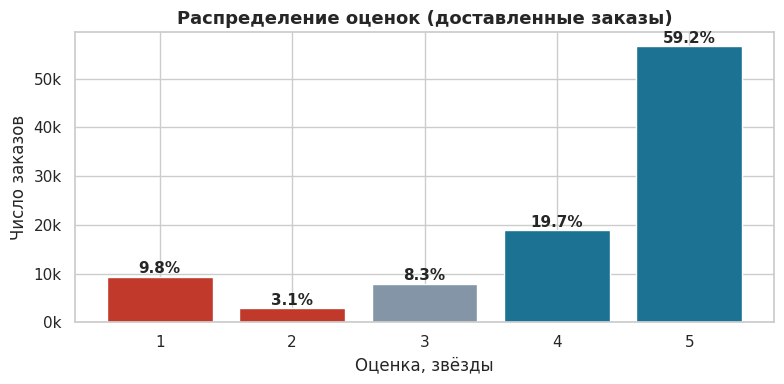

,заказов,"доля, %"
review_score,,
1,9379,9.8
2,2930,3.1
3,7920,8.3
4,18897,19.7
5,56697,59.2


In [4]:
score_counts = df.review_score.value_counts().sort_index()
score_share = (score_counts / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
colors = [BAD, BAD, NEUTRAL, OK, OK]
bars = ax.bar(score_counts.index, score_counts.values, color=colors)
for b, pct in zip(bars, score_share.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 700,
            f"{pct}%", ha="center", fontsize=11, fontweight="bold")
ax.set_title("Распределение оценок (доставленные заказы)")
ax.set_xlabel("Оценка, звёзды")
ax.set_ylabel("Число заказов")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
plt.tight_layout(); plt.show()

pd.DataFrame({"заказов": score_counts, "доля, %": score_share})

**Вывод.** Распределение сильно смещено вправо: почти две трети клиентов ставят
5 звёзд. Это типично для маркетплейсов — оценку чаще оставляют либо очень
довольные, либо очень недовольные, и «молчаливое большинство» склоняется
к пятёрке.

Для нас это значит две вещи. Первая: интересующий бизнес класс (недовольные)
— **меньшинство**, и модель придётся оценивать метриками, устойчивыми
к дисбалансу. Вторая: между 4 и 5 звёздами разница для бизнеса невелика —
обе означают «клиент доволен», поэтому предсказывать точную оценку
бессмысленно, задачу надо свести к бинарной.

### 2.1 Почему в выборке только доставленные заказы

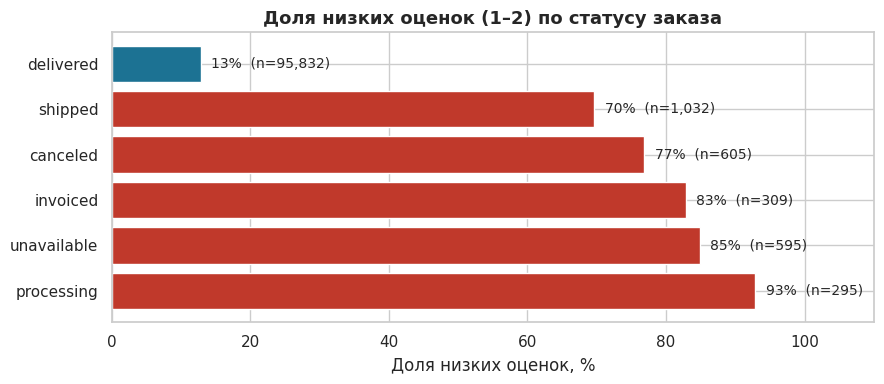

In [5]:
# Проверяем, что происходит с оценками у недоставленных заказов —
# это обоснование того, почему мы ограничили выборку статусом 'delivered'
with sqlite3.connect(DB_PATH) as conn:
    status_df = pd.read_sql("""
        SELECT o.order_status,
               AVG(CASE WHEN r.review_score <= 2 THEN 1.0 ELSE 0.0 END) AS low_rate,
               COUNT(*) AS n
        FROM orders o
        JOIN (SELECT order_id, MIN(review_score) AS review_score
              FROM order_reviews GROUP BY order_id) r
          ON r.order_id = o.order_id
        GROUP BY o.order_status
        HAVING n >= 100
        ORDER BY low_rate DESC
    """, conn)

fig, ax = plt.subplots(figsize=(9, 4))
cols = [BAD if v > 0.5 else OK for v in status_df.low_rate]
ax.barh(status_df.order_status, status_df.low_rate * 100, color=cols)
for i, (v, n) in enumerate(zip(status_df.low_rate * 100, status_df.n)):
    ax.text(v + 1.5, i, f"{v:.0f}%  (n={n:,})", va="center", fontsize=10)
ax.set_title("Доля низких оценок (1–2) по статусу заказа")
ax.set_xlabel("Доля низких оценок, %")
ax.set_xlim(0, 110)
plt.tight_layout(); plt.show()

**Вывод.** Если заказ так и не доехал — оценка почти гарантированно низкая:
у статусов `processing`, `unavailable`, `canceled` доля недовольных
**70–93%**, против **12.8%** у доставленных.

Предсказывать это незачем — тут нет задачи машинного обучения, достаточно
правила «заказ завис → клиент будет недоволен». Поэтому из выборки они
исключены, и вся дальнейшая работа идёт по доставленным заказам. Это
одновременно делает задачу **честнее и сложнее**: мы убрали самый очевидный
сигнал и работаем там, где ответ неочевиден.

### 2.2 Выбор порога бинаризации

In [6]:
for thr in (2, 3):
    share = (df.review_score <= thr).mean()
    print(f"Порог 1-{thr} звезды считаем негативом: "
          f"{share:.1%} позитивного класса ({(df.review_score <= thr).sum():,} заказов)")

Порог 1-2 звезды считаем негативом: 12.8% позитивного класса (12,309 заказов)
Порог 1-3 звезды считаем негативом: 21.1% позитивного класса (20,229 заказов)


In [7]:
# Фиксируем целевую переменную: 1 = клиент недоволен (1-2 звезды)
df["low_review"] = (df.review_score <= 2).astype(int)
BASE_RATE = df.low_review.mean()
print(f"Базовая доля негатива (baseline): {BASE_RATE:.2%}")

Базовая доля негатива (baseline): 12.85%


**Вывод и обоснование порога.** Взят порог **1–2 звезды = негатив**, а 3–5 = не негатив.

Рассуждение с точки зрения бизнеса: оценка в 3 звезды — это «нормально, но
без восторга». Такой клиент не пишет разгромный отзыв и не наносит
репутационного ущерба, а значит не является целью для дорогого вмешательства
(компенсации, звонка поддержки). А вот 1–2 звезды — это именно тот публичный
негатив, который бьёт по рейтингу продавца и по повторным покупкам.

Практическое следствие: при пороге 1–2 негативный класс составляет **12.8%**
выборки. Если бы мы взяли 1–3, класс вырос бы до ~21%, задача стала бы проще
статистически, но бизнес-смысл размылся бы — модель начала бы поднимать тревогу
по клиентам, которые в целом не проблемны.

## 3. Пропущенные значения

In [8]:
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_tbl = pd.DataFrame({"пропусков": miss, "доля, %": (miss / len(df) * 100).round(2)})
miss_tbl

,пропусков,"доля, %"
product_photos_qty,1349,1.41
product_volume_cm3,16,0.02
product_weight_g,16,0.02
seller_handling_days,15,0.02
approval_hours,14,0.01


**Вывод.** Пропусков в данных очень мало — максимум **1.4%** у одного столбца,
у остальных доли процента. Причины разные, и обрабатывать их нужно по-разному:

- `product_photos_qty`, `product_weight_g`, `product_volume_cm3` — в справочнике
  товаров нет карточки для этого `product_id`. Это пропуск «нет данных», для
  деревянных моделей его можно оставить как есть (HistGradientBoosting умеет
  работать с NaN), для линейной — заполнить медианой.
- `seller_handling_days`, `approval_hours` — не заполнена дата подтверждения
  оплаты или передачи в доставку. Тоже техническая нехватка данных, 15 строк
  из 95 823.

Отдельно стоит отметить `product_category`: физических пропусков там нет,
потому что в SQL-запросе они уже свёрнуты в категорию `'unknown'`. Проверим,
насколько велика эта группа.

In [9]:
unk = (df.product_category == "unknown").sum()
print(f"Заказов с неизвестной категорией товара: {unk:,} ({unk/len(df):.2%})")
print(f"Доля негатива внутри этой группы: {df.loc[df.product_category=='unknown','low_review'].mean():.2%}")
print(f"Доля негатива в среднем по выборке:  {BASE_RATE:.2%}")

Заказов с неизвестной категорией товара: 1,369 (1.43%)
Доля негатива внутри этой группы: 16.73%
Доля негатива в среднем по выборке:  12.85%


**Вывод.** Группа `unknown` небольшая (1.4% заказов), но уровень негатива
в ней **16.7% против 12.8% в среднем** — заметно выше. То есть отсутствие
карточки товара в справочнике само по себе слабо коррелирует с проблемным
заказом: скорее всего, это редкие или плохо заведённые позиции, по которым
клиенту труднее понять, что он покупает.

Практический вывод: удалять эти строки нельзя — они несут сигнал. `unknown`
остаётся как полноценное отдельное значение категории, а не как «мусор».

## 4. Сроки доставки — главный фактор

Это основная гипотеза проекта: клиент недоволен прежде всего тогда, когда
заказ пришёл позже обещанного. Проверяем.

In [10]:
# ВАЖНО: обещанная дата (order_estimated_delivery_date) хранится как календарная
# дата с временем 00:00:00, а фактическая доставка — с реальным временем.
# Поэтому дробная разница через JULIANDAY в SQL некорректна: доставка в 15:00
# в обещанный день выглядит как "опоздание на 0.6 дня", хотя срок соблюдён.
# Пересчитываем опоздание на уровне календарных дней.
with sqlite3.connect(DB_PATH) as conn:
    dates = pd.read_sql("""
        SELECT order_id,
               order_delivered_customer_date AS delivered,
               order_estimated_delivery_date  AS promised
        FROM orders
    """, conn)

dates["delivered"] = pd.to_datetime(dates.delivered)
dates["promised"]  = pd.to_datetime(dates.promised)
dates["late_days"] = (dates.delivered.dt.normalize() - dates.promised.dt.normalize()).dt.days

df = df.merge(dates[["order_id", "late_days"]], on="order_id", how="left")
df["is_late"] = (df.late_days > 0).astype(int)

# Сравниваем две версии, чтобы показать масштаб искажения
frac_late = (-df.days_early_vs_estimate > 0).mean()
print(f"Доля 'опоздавших' по дробной версии из SQL: {frac_late:.2%}  <- завышена")
print(f"Доля опоздавших по календарным дням:        {df.is_late.mean():.2%}  <- корректно")
print(f"Медиана опоздания: {df.late_days.median():.0f} дн. (типичный заказ приезжает раньше срока)")

Доля 'опоздавших' по дробной версии из SQL: 7.99%  <- завышена
Доля опоздавших по календарным дням:        6.66%  <- корректно
Медиана опоздания: -12 дн. (типичный заказ приезжает раньше срока)


**Замечание по качеству данных.** Обещанная дата доставки в Olist хранится как
календарная дата (время всегда `00:00:00`), а факт доставки — с точным временем.
Из-за этого прямая дробная разница дат завышает число опозданий на четверть
(8.0% против 6.7%): любой заказ, вручённый днём в обещанную дату, формально
оказывается «опоздавшим на несколько часов», хотя срок соблюдён.

Дальше используется корректная версия — разница в календарных днях. Этот же
признак нужно поправить в SQL-запросе перед этапом моделирования, иначе модель
получит зашумлённый вход по самому важному фактору.

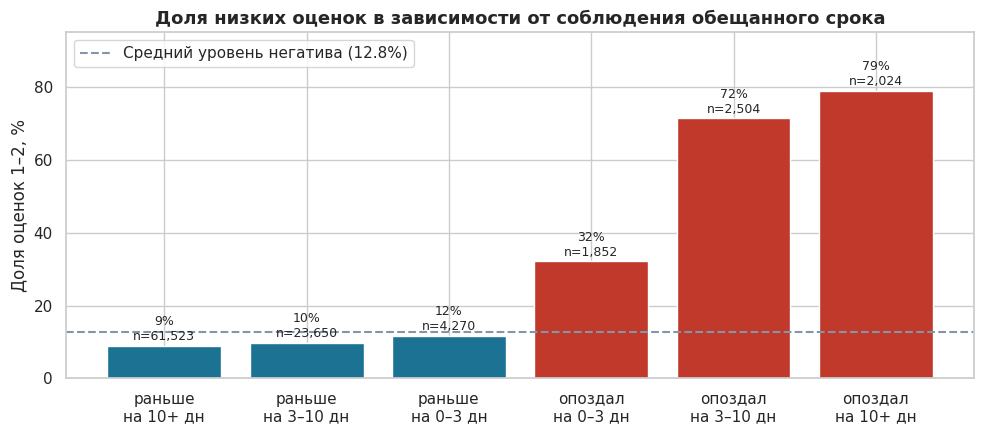

,late_bucket,low_rate,n
0,раньше\nна 10+ дн,8.9,61523
1,раньше\nна 3–10 дн,9.8,23650
2,раньше\nна 0–3 дн,11.8,4270
3,опоздал\nна 0–3 дн,32.2,1852
4,опоздал\nна 3–10 дн,71.5,2504
5,опоздал\nна 10+ дн,79.0,2024


In [11]:
bins   = [-np.inf, -10, -3, 0, 3, 10, np.inf]
labels = ["раньше\nна 10+ дн", "раньше\nна 3–10 дн", "раньше\nна 0–3 дн",
          "опоздал\nна 0–3 дн", "опоздал\nна 3–10 дн", "опоздал\nна 10+ дн"]
df["late_bucket"] = pd.cut(df.late_days, bins=bins, labels=labels)

g = df.groupby("late_bucket", observed=True).agg(
    low_rate=("low_review", "mean"), n=("low_review", "size")
).reset_index()

fig, ax = plt.subplots(figsize=(10, 4.5))
cols = [BAD if v > 0.3 else OK for v in g.low_rate]
bars = ax.bar(g.late_bucket.astype(str), g.low_rate * 100, color=cols)
for b, v, n in zip(bars, g.low_rate * 100, g.n):
    ax.text(b.get_x() + b.get_width()/2, v + 1.5,
            f"{v:.0f}%\nn={n:,}", ha="center", fontsize=9)
ax.axhline(BASE_RATE * 100, color=NEUTRAL, ls="--", lw=1.5,
           label=f"Средний уровень негатива ({BASE_RATE:.1%})")
ax.set_title("Доля низких оценок в зависимости от соблюдения обещанного срока")
ax.set_ylabel("Доля оценок 1–2, %")
ax.set_ylim(0, 95)
ax.legend()
plt.tight_layout(); plt.show()

g.assign(low_rate=(g.low_rate*100).round(1))

**Вывод — и это ключевая находка всего EDA.**

Опоздание работает как выключатель, а не как плавный фактор. Пока заказ
приезжает вовремя или раньше, доля негатива держится на уровне 9–12%.
Но стоит нарушить обещанный срок хотя бы на день — она **скачком вырастает
до 32%**, при опоздании на 3–10 дней доходит до **72%**, а свыше десяти
дней — до **79%**. Разница между крайними группами почти девятикратная.

При этом есть принципиальное ограничение, которое надо честно держать в
голове при оценке будущей модели: **опоздавших заказов всего ~6.7%**.
То есть самый сильный признак в датасете покрывает лишь малую часть выборки.
Остальные 93% заказов доставлены в срок, и у них те же базовые 9–12% негатива,
причины которого (не тот товар, плохое качество, несовпадение с ожиданиями)
в наших данных попросту отсутствуют.

Это заранее задаёт **потолок качества модели** и объясняет, почему высокого
F1 в этой задаче ждать не стоит.

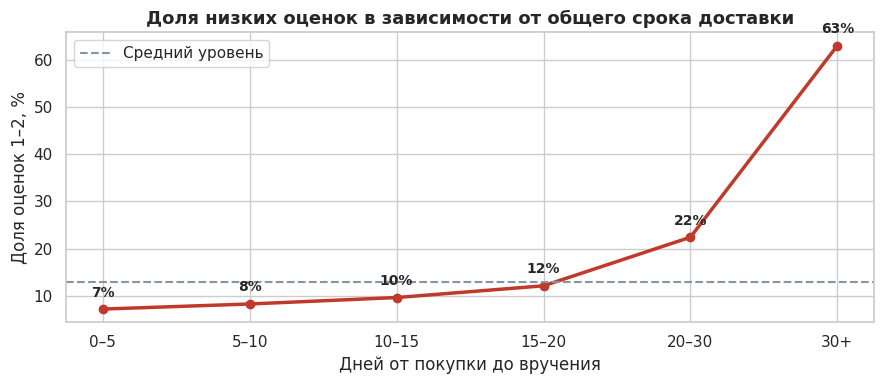

In [12]:
# Смотрим на абсолютную длительность доставки, а не только на отклонение от обещания
df["deliv_bucket"] = pd.cut(df.delivery_days, [0, 5, 10, 15, 20, 30, np.inf],
                            labels=["0–5", "5–10", "10–15", "15–20", "20–30", "30+"])
g2 = df.groupby("deliv_bucket", observed=True).agg(
    low_rate=("low_review", "mean"), n=("low_review", "size")).reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(g2.deliv_bucket.astype(str), g2.low_rate * 100, marker="o", lw=2.5, color=BAD)
for x, v, n in zip(range(len(g2)), g2.low_rate*100, g2.n):
    ax.annotate(f"{v:.0f}%", (x, v), textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=10, fontweight="bold")
ax.axhline(BASE_RATE * 100, color=NEUTRAL, ls="--", lw=1.5, label="Средний уровень")
ax.set_title("Доля низких оценок в зависимости от общего срока доставки")
ax.set_xlabel("Дней от покупки до вручения")
ax.set_ylabel("Доля оценок 1–2, %")
ax.legend()
plt.tight_layout(); plt.show()

**Вывод.** Абсолютный срок доставки тоже влияет, но гораздо мягче: рост
монотонный, без резких скачков. Даже доставка за 30+ дней даёт уровень
негатива ниже, чем трёхдневное опоздание относительно обещанного срока.

Это важный управленческий инсайт: клиента раздражает **не долгая доставка
сама по себе, а нарушение данного ему обещания**. Один и тот же срок
в 25 дней воспринимается нормально, если его назвали заранее, и как провал,
если обещали 12.

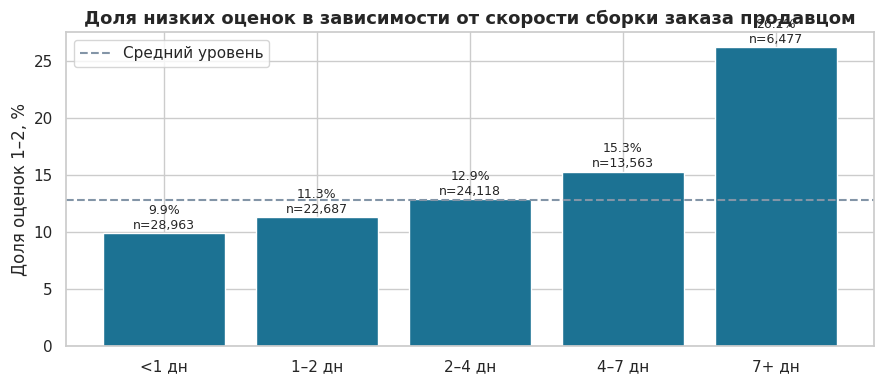

In [13]:
# Время реакции продавца: сколько он собирал заказ до передачи в доставку
df["handling_bucket"] = pd.cut(df.seller_handling_days, [-np.inf, 1, 2, 4, 7, np.inf],
                               labels=["<1 дн", "1–2 дн", "2–4 дн", "4–7 дн", "7+ дн"])
g3 = df.groupby("handling_bucket", observed=True).agg(
    low_rate=("low_review", "mean"), n=("low_review", "size")).reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(g3.handling_bucket.astype(str), g3.low_rate * 100, color=OK)
for b, v, n in zip(bars, g3.low_rate*100, g3.n):
    ax.text(b.get_x()+b.get_width()/2, v+0.4, f"{v:.1f}%\nn={n:,}",
            ha="center", fontsize=9)
ax.axhline(BASE_RATE * 100, color=NEUTRAL, ls="--", lw=1.5, label="Средний уровень")
ax.set_title("Доля низких оценок в зависимости от скорости сборки заказа продавцом")
ax.set_ylabel("Доля оценок 1–2, %")
ax.legend()
plt.tight_layout(); plt.show()

**Вывод.** Медленная сборка на стороне продавца повышает риск негатива —
от ~11% при отгрузке в первый день до ~22% при задержке свыше недели.
Эффект вдвое слабее, чем у срыва обещанной даты, но он есть и, в отличие
от работы курьерской службы, **напрямую управляем продавцом** — поэтому
для бизнеса это практически полезный рычаг.

## 5. Товар, цена и способ оплаты

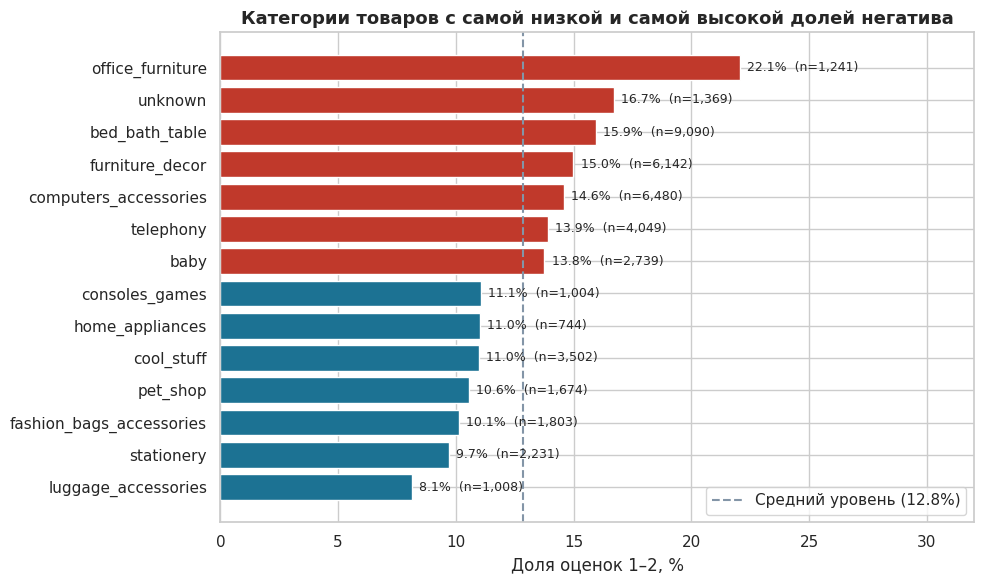

In [14]:
# Категории: берём только достаточно крупные, чтобы доля была статистически осмысленной
cat = df.groupby("product_category").agg(
    low_rate=("low_review", "mean"), n=("low_review", "size"))
cat = cat[cat.n >= 500].sort_values("low_rate")

top = pd.concat([cat.head(7), cat.tail(7)])

fig, ax = plt.subplots(figsize=(10, 6))
cols = [BAD if v > BASE_RATE else OK for v in top.low_rate]
ax.barh(top.index, top.low_rate * 100, color=cols)
ax.axvline(BASE_RATE * 100, color=NEUTRAL, ls="--", lw=1.5,
           label=f"Средний уровень ({BASE_RATE:.1%})")
for i, (v, n) in enumerate(zip(top.low_rate*100, top.n)):
    ax.text(v + 0.3, i, f"{v:.1f}%  (n={n:,})", va="center", fontsize=9)
ax.set_title("Категории товаров с самой низкой и самой высокой долей негатива")
ax.set_xlabel("Доля оценок 1–2, %")
ax.set_xlim(0, 32)
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

**Вывод.** Разброс между категориями заметный — от **8.1%** до **22.1%**
негатива, то есть почти трёхкратный.

Хуже всего — офисная мебель (22.1%), товары для спальни и ванной (15.9%),
мебель и декор (15.0%). Это крупногабаритные товары, которые сложно оценить
по фотографии и легко получить «не таким, как представлял»; заодно их дольше
и рискованнее везти. Лучше всего — аксессуары для багажа (8.1%), канцелярия
(9.7%), сумки (10.1%): простые предметы с предсказуемым результатом, где
ожидания клиента совпадают с тем, что приезжает.

Для модели это значит, что категория — полезный признак, но эффект у неё
намного слабее срыва срока. Для бизнеса — что проблемные категории стоит
разбирать отдельно: возможно, там нужны более подробные карточки товара
или более осторожные сроки доставки.

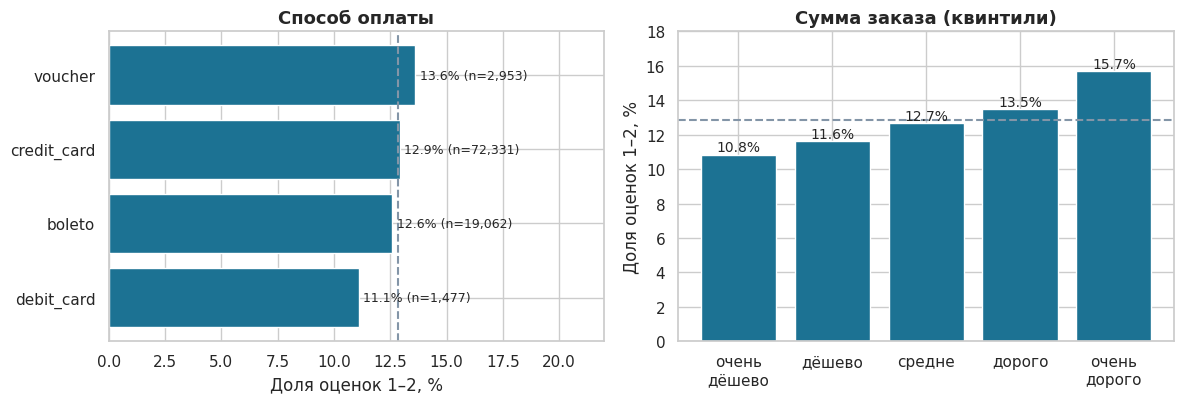

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Способ оплаты
pay = df.groupby("payment_type").agg(
    low_rate=("low_review", "mean"), n=("low_review", "size"))
pay = pay[pay.n >= 500].sort_values("low_rate")
axes[0].barh(pay.index, pay.low_rate*100, color=OK)
axes[0].axvline(BASE_RATE*100, color=NEUTRAL, ls="--", lw=1.5)
for i, (v, n) in enumerate(zip(pay.low_rate*100, pay.n)):
    axes[0].text(v+0.2, i, f"{v:.1f}% (n={n:,})", va="center", fontsize=9)
axes[0].set_title("Способ оплаты")
axes[0].set_xlabel("Доля оценок 1–2, %")
axes[0].set_xlim(0, 22)

# Цена заказа
df["price_bucket"] = pd.qcut(df.total_price, 5, labels=["очень\nдёшево", "дёшево",
                                                        "средне", "дорого", "очень\nдорого"])
pr = df.groupby("price_bucket", observed=True).low_review.mean()
axes[1].bar(pr.index.astype(str), pr.values*100, color=OK)
axes[1].axhline(BASE_RATE*100, color=NEUTRAL, ls="--", lw=1.5)
for x, v in enumerate(pr.values*100):
    axes[1].text(x, v+0.2, f"{v:.1f}%", ha="center", fontsize=10)
axes[1].set_title("Сумма заказа (квинтили)")
axes[1].set_ylabel("Доля оценок 1–2, %")
axes[1].set_ylim(0, 18)

plt.tight_layout(); plt.show()

**Вывод.** Оба фактора влияют слабо — колебания в пределах пары процентных
пунктов вокруг среднего уровня.

По оплате небольшой перевес негатива у `boleto` (бразильский банковский
платёжный слип): он требует ручной оплаты в банке или приложении, из-за чего
подтверждение занимает дольше — то есть эффект, скорее всего, снова упирается
в сроки, а не в сам способ оплаты.

По сумме заказа выраженной зависимости нет: дорогие покупки не вызывают
систематически больше недовольства, чем дешёвые. Это опровергает интуитивную
гипотезу «чем дороже, тем выше ожидания и тем злее клиент» — как минимум
на этих данных она не подтверждается.

## 6. География

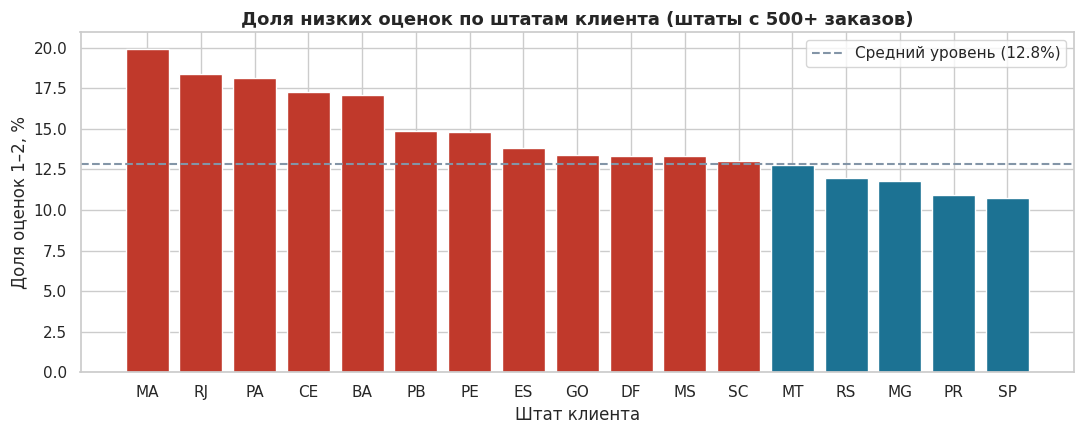

Средний срок доставки в худших и лучших штатах:
customer_state
MA    21.4
PA    23.6
RJ    15.2
Name: delivery_days, dtype: float64
customer_state
MG    12.0
PR    12.0
SP     8.7
Name: delivery_days, dtype: float64


In [16]:
st = df.groupby("customer_state").agg(
    low_rate=("low_review", "mean"), n=("low_review", "size"))
st = st[st.n >= 500].sort_values("low_rate", ascending=False)

fig, ax = plt.subplots(figsize=(11, 4.5))
cols = [BAD if v > BASE_RATE else OK for v in st.low_rate]
ax.bar(st.index, st.low_rate*100, color=cols)
ax.axhline(BASE_RATE*100, color=NEUTRAL, ls="--", lw=1.5,
           label=f"Средний уровень ({BASE_RATE:.1%})")
ax.set_title("Доля низких оценок по штатам клиента (штаты с 500+ заказов)")
ax.set_ylabel("Доля оценок 1–2, %")
ax.set_xlabel("Штат клиента")
ax.legend()
plt.tight_layout(); plt.show()

print("Средний срок доставки в худших и лучших штатах:")
worst, best = st.index[:3].tolist(), st.index[-3:].tolist()
print(df[df.customer_state.isin(worst)].groupby('customer_state').delivery_days.mean().round(1))
print(df[df.customer_state.isin(best)].groupby('customer_state').delivery_days.mean().round(1))

**Вывод.** География заметно влияет: разрыв между худшими и лучшими штатами
почти двукратный. Но это не самостоятельный фактор — сравнение средних сроков
доставки показывает, что проблемные штаты это удалённые регионы, куда посылка
идёт в 1.5–2 раза дольше. То есть география работает **через доставку**,
а не помимо неё.

Практический смысл: проблема не в клиентах из определённых регионов,
а в том, что логистика в эти регионы систематически не укладывается
в заявленные сроки.

In [17]:
same = df.groupby("same_state").agg(
    low_rate=("low_review", "mean"), n=("low_review", "size"),
    avg_days=("delivery_days", "mean"))
same.index = ["Разные штаты", "Один штат"]
same.assign(low_rate=(same.low_rate*100).round(1), avg_days=same.avg_days.round(1))

,low_rate,n,avg_days
Разные штаты,14.2,61346,15.1
Один штат,10.5,34477,7.9


**Вывод.** Когда продавец и клиент в одном штате, доставка быстрее примерно
вдвое, и доля негатива заметно ниже. Это подтверждает тот же вывод другим
способом и подсказывает бизнесу конкретное действие: приоритизировать
в выдаче локальных продавцов там, где это возможно.

## 7. Сводка по силе признаков

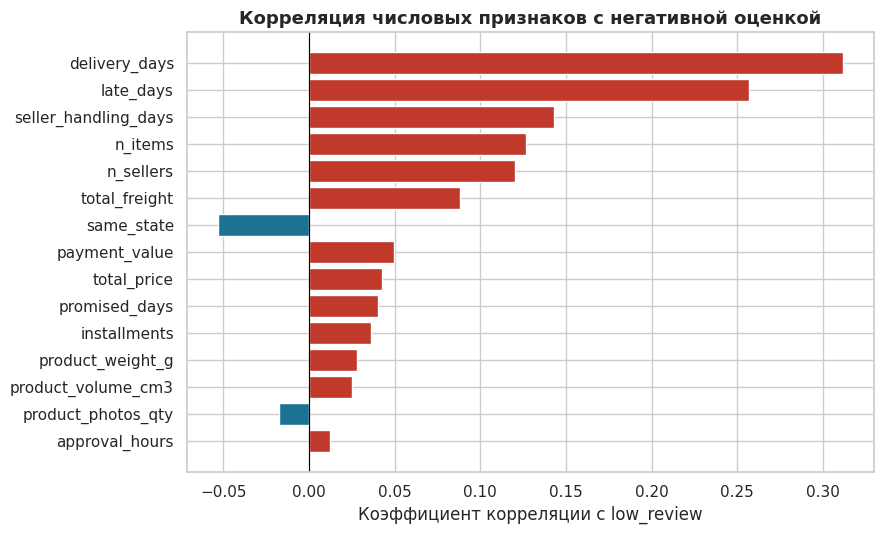

,корреляция
delivery_days,0.312
late_days,0.257
seller_handling_days,0.143
n_items,0.126
n_sellers,0.120
total_freight,0.088
same_state,-0.053
payment_value,0.050
total_price,0.043
promised_days,0.041


In [18]:
num_cols = ["late_days", "delivery_days", "promised_days", "seller_handling_days",
            "approval_hours", "n_items", "n_sellers", "total_price", "total_freight",
            "payment_value", "installments", "product_weight_g", "product_photos_qty",
            "product_volume_cm3", "same_state"]

corr = df[num_cols + ["low_review"]].corr()["low_review"].drop("low_review")
corr = corr.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
cols = [BAD if v > 0 else OK for v in corr.values]
ax.barh(corr.index[::-1], corr.values[::-1], color=cols[::-1])
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Корреляция числовых признаков с негативной оценкой")
ax.set_xlabel("Коэффициент корреляции с low_review")
plt.tight_layout(); plt.show()

corr.round(3).to_frame("корреляция")

**Вывод.** Первые места ожидаемо занимают признаки сроков — `delivery_days`
(0.31) и `late_days` (0.26). Дальше идёт скорость сборки заказа продавцом
(0.14), и вместе с ней — два признака, которые мы отдельно не разбирали:
**`n_items` (0.13) и `n_sellers` (0.12)**. Заказы из нескольких позиций,
особенно собранные у разных продавцов, заметно рискованнее: посылка едет
частями, и достаточно одной задержавшейся, чтобы впечатление испортилось.
Остальные признаки — цена, вес, число фото, способ оплаты — практически
на нуле, что согласуется с графиками выше.

Две оговорки к чтению этой диаграммы:

1. Корреляция **занижает** силу опоздания, потому что измеряет линейную связь,
   а зависимость у нас пороговая («уложились / не уложились»), а не плавная.
   Формально `delivery_days` здесь обходит `late_days`, но в разрезе по
   корзинам видно обратное: срыв срока разделяет классы куда резче, чем
   абсолютная длительность. Поэтому в моделировании стоит добавить явный
   бинарный признак `is_late` — деревянные модели найдут порог и сами,
   но линейной модели это заметно поможет.
2. `delivery_days` и `late_days` сильно связаны между собой, так что для
   линейной модели их совместное использование даст мультиколлинеарность —
   на это стоит посмотреть отдельно на этапе обучения.

## 8. Итоги EDA

**1. Целевая переменная.** Оценки сильно смещены к 5 звёздам. Задача сведена
к бинарной с порогом 1–2 звезды = негатив; такой класс составляет **12.8%**
выборки. Дисбаланс умеренный, но достаточный, чтобы accuracy стала
бесполезной метрикой — ориентироваться нужно на PR-AUC и F1 с подбором порога.

**2. Пропуски.** Их мало (максимум 1.4% в одном столбце) и все они носят
технический характер — отсутствие карточки товара или незаполненная служебная
дата. Ни удалять строки, ни строить сложную импутацию не требуется.

**3. Главный фактор — соблюдение обещанного срока, а не скорость доставки.**
Срыв обещанной даты поднимает долю негатива с 9–12% до 32–79%. При этом
абсолютно долгая, но предсказанная заранее доставка переносится клиентами
гораздо спокойнее.

**4. Второстепенные факторы.** Скорость сборки заказа продавцом (управляемый
рычаг), состав заказа (несколько позиций от разных продавцов — выше риск),
категория товара (разброс от 8% до 22%) и география — последняя работает
опосредованно, через сроки доставки. Цена и способ оплаты практически
не влияют.

**5. Ограничение, важное для следующего этапа.** Опоздавших заказов всего
**6.7%** выборки. Самый сильный сигнал покрывает малую часть данных, а для
остальных 93% заказов причины негатива (качество товара, несовпадение
с ожиданиями) в датасете отсутствуют физически. Это объективный потолок
качества: модель сможет уверенно находить проблемные заказы среди опоздавших,
но останется почти слепой к негативу по «товарным» причинам.

Следующий шаг — часть 3: обучение и сравнение моделей с учётом этого
ограничения и осознанным выбором метрики.